## 0. Imports and shared configuration

In [1]:
import warnings
from collections import defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

warnings.filterwarnings('ignore')

# Project imports
from simulation import Simulation
from welfare_layer import WelfareAwareOrchestrator, TravelCostEstimator
from oracle_rs import OracleRecommender, OracleOrchestrator, register_agent_from_abm
from experiment_harness import (
    gini_coefficient, over_recommendation_cost, calibrate_rm_epsilon,
)

print('Imports OK.')

Imports OK.


In [2]:
# ── Simulation parameters (shared across every section) ─────────────────
NUM_AGENTS = 250        # agents per simulation
CITY_SIZE  = 18         # grid dimension
NUM_DAYS   = 14         # simulation horizon
TIME_STEP  = 5          # minutes per tick
SEEDS      = [11, 13, 17, 19, 23]   # matched seeds for variance estimation
CONTEXT    = {'weather': 'fair', 'travel_norm': 'neutral'}

# ── Welfare-constraint thresholds used by the ORC treatments ───────────
PUP_ALPHA  = 0.3        # P(U >= 0) must exceed this
RM_EPSILON = 0.2721     # E[regret] must be below this

# ── Treatments for Table 1, the paradigm heatmap, and the ORC table ────
TREATMENTS = [
    {'name': 'no_rs',    'use_rs': False, 'factory': None},
    {'name': 'standard', 'use_rs': True,  'factory': None},
    {'name': 'pup_03',   'use_rs': True,  'factory': 'pup', 'pup_alpha': 0.3},
    {'name': 'pup_07',   'use_rs': True,  'factory': 'pup', 'pup_alpha': 0.7},
    {'name': 'rm',       'use_rs': True,  'factory': 'rm',  'rm_epsilon': RM_EPSILON},
    {'name': 'oracle',   'use_rs': True,  'factory': 'oracle'},
]

# Display labels for tables/plots
DISPLAY_NAMES = {
    'no_rs':    'No RS',
    'standard': 'Standard RS',
    'pup_03':   'PUP-0.3',
    'pup_07':   'PUP-0.7',
    'rm':       f'RM ($\\epsilon$={RM_EPSILON})',
    'oracle':   'Oracle',
}

# ── Sweep ranges used only for the frontier figures (Figs 2 & 3) ───────
PUP_ALPHAS     = [0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]
RM_PERCENTILES = [50, 60, 65, 70, 75, 80, 90]

print(f'{NUM_AGENTS} agents · {CITY_SIZE}x{CITY_SIZE} city · {NUM_DAYS} days · {len(SEEDS)} seeds')
print(f'Treatments: {[t["name"] for t in TREATMENTS]}')

250 agents · 18x18 city · 14 days · 5 seeds
Treatments: ['no_rs', 'standard', 'pup_03', 'pup_07', 'rm', 'oracle']


In [3]:
# ── Factory helpers ─────────────────────────────────────────────────────
def _make_pup_factory(alpha):
    def factory(sim, base_stack):
        tce = TravelCostEstimator(default_vot=15.0, learning_rate=0.15)
        return WelfareAwareOrchestrator(
            base_orchestrator=base_stack, travel_cost_estimator=tce,
            mode='pup', pup_alpha=alpha, coord_scale_km=sim.city.block_km,
        )
    return factory


def _make_rm_factory(epsilon):
    def factory(sim, base_stack):
        tce = TravelCostEstimator(default_vot=15.0, learning_rate=0.15)
        return WelfareAwareOrchestrator(
            base_orchestrator=base_stack, travel_cost_estimator=tce,
            mode='rm', rm_epsilon=epsilon, coord_scale_km=sim.city.block_km,
        )
    return factory


def _make_standard_factory():
    def factory(sim, base_stack):
        tce = TravelCostEstimator(default_vot=15.0, learning_rate=0.15)
        return WelfareAwareOrchestrator(
            base_orchestrator=base_stack, travel_cost_estimator=tce,
            mode='standard', coord_scale_km=sim.city.block_km,
        )
    return factory


def _make_oracle_factory():
    def factory(sim, base_stack):
        oracle = OracleRecommender(sim.place_catalog, coord_scale_km=sim.city.block_km)
        for agent in sim.agents:
            register_agent_from_abm(oracle, agent)
        return OracleOrchestrator(oracle)
    return factory


def _treatment_to_factory(treatment):
    """Turn a treatment dict into (use_rs, recommender_factory)."""
    if not treatment['use_rs']:
        return False, None
    ft = treatment.get('factory')
    if ft is None:
        return True, _make_standard_factory()
    if ft == 'pup':
        return True, _make_pup_factory(treatment['pup_alpha'])
    if ft == 'rm':
        return True, _make_rm_factory(treatment['rm_epsilon'])
    if ft == 'oracle':
        return True, _make_oracle_factory()
    raise ValueError(f'Unknown factory: {ft}')


def run_single(seed, use_recommenders=True, recommender_factory=None):
    """Run one simulation and return metrics needed by every section."""
    sim = Simulation(
        num_agents=NUM_AGENTS, city_size=CITY_SIZE, seed=seed,
        time_step=TIME_STEP, context=CONTEXT,
        use_recommenders=use_recommenders,
        recommender_factory=recommender_factory,
    )
    sim.run_days(num_days=NUM_DAYS)
    summary = sim.summarize()

    trip_utilities = []
    agent_utilities = {}   # agent_id -> total leisure utility
    agent_data = []        # one row per agent (for heterogeneity)
    for agent in sim.agents:
        leisure_trips = [t for t in agent.trips if t.purpose == 'leisure']
        utilities = [t.utility for t in leisure_trips]
        trip_utilities.extend(utilities)
        agent_utilities[agent.id] = float(sum(utilities))
        agent_data.append({
            'agent_id': agent.id,
            'paradigm': agent.decision_paradigms.get('mode_choice', 'utility'),
            'mean_utility': float(np.mean(utilities)) if utilities else 0.0,
            'total_utility': float(sum(utilities)),
            'num_leisure_trips': len(leisure_trips),
        })

    abstention_rate = 1.0 - summary.get('recommendation_acceptance_rate', 0.0)
    neg_rate = (sum(1 for u in trip_utilities if u < 0) / max(1, len(trip_utilities)))

    return {
        'trip_utilities':  trip_utilities,
        'agent_utilities': agent_utilities,
        'agent_data':      agent_data,
        'mean_utility':    float(np.mean(trip_utilities)) if trip_utilities else 0.0,
        'neg_utility_rate': neg_rate,
        'gini':             gini_coefficient(trip_utilities),
        'abstention_rate':  abstention_rate,
        'n_trips':          len(trip_utilities),
    }


print('Helpers defined.')

Helpers defined.


In [4]:
# ── Run the six Table-1 / heatmap / ORC treatments once and cache them ──
results = {}   # (treatment_name, seed) -> run_single(...) dict

for treatment in TREATMENTS:
    tname = treatment['name']
    use_rs, factory = _treatment_to_factory(treatment)
    print(f'\nTreatment: {tname}')
    for seed in SEEDS:
        print(f'  seed={seed}', end=' ')
        res = run_single(seed, use_recommenders=use_rs, recommender_factory=factory)
        results[(tname, seed)] = res
        print(f'done (mean U={res["mean_utility"]:.4f}, n={res["n_trips"]})')

print(f'\nCached {len(results)} matched (treatment, seed) runs.')


Treatment: no_rs
  seed=11 done (mean U=-0.0044, n=137)
  seed=13 done (mean U=0.0175, n=147)
  seed=17 done (mean U=0.0588, n=148)
  seed=19 done (mean U=0.1043, n=145)
  seed=23 done (mean U=0.0476, n=151)

Treatment: standard
  seed=11 done (mean U=0.1233, n=155)
  seed=13 done (mean U=0.1090, n=141)
  seed=17 done (mean U=0.0797, n=152)
  seed=19 done (mean U=0.0516, n=145)
  seed=23 done (mean U=0.0522, n=164)

Treatment: pup_03
  seed=11 done (mean U=0.2383, n=144)
  seed=13 done (mean U=0.2521, n=150)
  seed=17 done (mean U=0.2596, n=158)
  seed=19 done (mean U=0.2276, n=144)
  seed=23 done (mean U=0.2593, n=162)

Treatment: pup_07
  seed=11 done (mean U=0.2354, n=153)
  seed=13 done (mean U=0.2495, n=156)
  seed=17 done (mean U=0.2714, n=156)
  seed=19 done (mean U=0.2380, n=157)
  seed=23 done (mean U=0.2404, n=160)

Treatment: rm
  seed=11 done (mean U=0.2343, n=155)
  seed=13 done (mean U=0.2103, n=151)
  seed=17 done (mean U=0.2598, n=149)
  seed=19 done (mean U=0.2455, n=

## 1. Sensitivity analysis

Finds the optimal $\alpha$ (for PUP, **Figure 2**) and $\epsilon$ (for RM, **Figure 3**) and reports the aggregate welfare comparison summary (**Table 1**).

In [5]:
# ── PUP α sweep (Figure 2) ──────────────────────────────────────────────
# We reuse the runs already cached in `results` for α = 0.3 and α = 0.7.
pup_cache_map = {0.3: 'pup_03', 0.7: 'pup_07'}
pup_results = {}   # alpha -> list of per-seed run dicts

for alpha in PUP_ALPHAS:
    if alpha in pup_cache_map and (pup_cache_map[alpha], SEEDS[0]) in results:
        pup_results[alpha] = [results[(pup_cache_map[alpha], s)] for s in SEEDS]
        print(f'PUP α = {alpha:.1f}  (reused from cache)')
        continue
    print(f'PUP α = {alpha:.1f}')
    runs = []
    for seed in SEEDS:
        print(f'  seed={seed}', end=' ')
        runs.append(run_single(seed, recommender_factory=_make_pup_factory(alpha)))
        print(f'done (mean U={runs[-1]["mean_utility"]:.4f})')
    pup_results[alpha] = runs

PUP α = 0.0
  seed=11 done (mean U=0.1233)
  seed=13 done (mean U=0.1090)
  seed=17 done (mean U=0.0797)
  seed=19 done (mean U=0.0516)
  seed=23 done (mean U=0.0522)
PUP α = 0.1
  seed=11 done (mean U=0.1708)
  seed=13 done (mean U=0.2115)
  seed=17 done (mean U=0.2306)
  seed=19 done (mean U=0.2138)
  seed=23 done (mean U=0.1518)
PUP α = 0.2
  seed=11 done (mean U=0.1975)
  seed=13 done (mean U=0.1871)
  seed=17 done (mean U=0.2187)
  seed=19 done (mean U=0.2687)
  seed=23 done (mean U=0.2624)
PUP α = 0.3  (reused from cache)
PUP α = 0.4
  seed=11 done (mean U=0.2307)
  seed=13 done (mean U=0.1948)
  seed=17 done (mean U=0.2497)
  seed=19 done (mean U=0.2126)
  seed=23 done (mean U=0.2262)
PUP α = 0.5
  seed=11 done (mean U=0.2003)
  seed=13 done (mean U=0.2295)
  seed=17 done (mean U=0.2411)
  seed=19 done (mean U=0.2045)
  seed=23 done (mean U=0.2625)
PUP α = 0.6
  seed=11 done (mean U=0.1707)
  seed=13 done (mean U=0.2244)
  seed=17 done (mean U=0.2932)
  seed=19 done (mean U=0.18

In [6]:
# ── RM ε calibration + sweep (Figure 3) ─────────────────────────────────
# Calibrate ε at each percentile using the Standard-RS trip-utility
# distribution (proxy regret = max(0, mean - trip_utility)).
std_utils = np.array(
    [u for s in SEEDS for u in results[('standard', s)]['trip_utilities']]
)
regret_proxy = np.maximum(0.0, np.mean(std_utils) - std_utils)

rm_epsilons = {p: calibrate_rm_epsilon(regret_proxy, percentile=p) for p in RM_PERCENTILES}
print('Calibrated RM ε values:')
for p, e in rm_epsilons.items():
    print(f'  p{p} → ε = {e:.4f}')

rm_results = {}   # percentile -> {'epsilon': ε, 'runs': [per-seed run dicts]}
for pct, eps in rm_epsilons.items():
    print(f'\nRM ε = {eps:.4f} (p{pct})')
    runs = []
    for seed in SEEDS:
        print(f'  seed={seed}', end=' ')
        runs.append(run_single(seed, recommender_factory=_make_rm_factory(eps)))
        print(f'done (mean U={runs[-1]["mean_utility"]:.4f})')
    rm_results[pct] = {'epsilon': eps, 'runs': runs}

Calibrated RM ε values:
  p50 → ε = 0.0000
  p60 → ε = 0.0554
  p65 → ε = 0.1213
  p70 → ε = 0.2002
  p75 → ε = 0.2721
  p80 → ε = 0.3770
  p90 → ε = 0.6328

RM ε = 0.0000 (p50)
  seed=11 done (mean U=-0.0044)
  seed=13 done (mean U=0.0175)
  seed=17 done (mean U=0.0588)
  seed=19 done (mean U=0.1043)
  seed=23 done (mean U=0.0476)

RM ε = 0.0554 (p60)
  seed=11 done (mean U=-0.0044)
  seed=13 done (mean U=0.0175)
  seed=17 done (mean U=0.0631)
  seed=19 done (mean U=0.1043)
  seed=23 done (mean U=0.0476)

RM ε = 0.1213 (p65)
  seed=11 done (mean U=0.0745)
  seed=13 done (mean U=0.1312)
  seed=17 done (mean U=0.2139)
  seed=19 done (mean U=0.1822)
  seed=23 done (mean U=0.1856)

RM ε = 0.2002 (p70)
  seed=11 done (mean U=0.2308)
  seed=13 done (mean U=0.2343)
  seed=17 done (mean U=0.2218)
  seed=19 done (mean U=0.2557)
  seed=23 done (mean U=0.2274)

RM ε = 0.2721 (p75)
  seed=11 done (mean U=0.2343)
  seed=13 done (mean U=0.2103)
  seed=17 done (mean U=0.2598)
  seed=19 done (mean U=

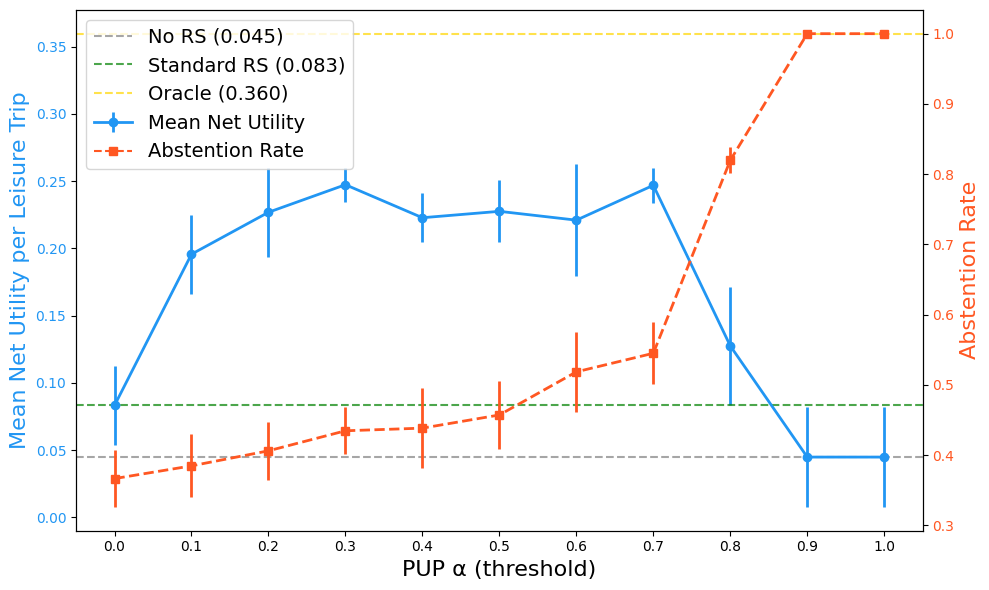

Best PUP α (max mean U) = 0.3 at U = 0.2474


In [7]:
# ── Figure 2: PUP threshold frontier ────────────────────────────────────
no_rs_mu  = np.mean([results[('no_rs',    s)]['mean_utility'] for s in SEEDS])
std_mu    = np.mean([results[('standard', s)]['mean_utility'] for s in SEEDS])
oracle_mu = np.mean([results[('oracle',   s)]['mean_utility'] for s in SEEDS])

color_u, color_a = '#2196F3', '#FF5722'
fig, ax1 = plt.subplots(figsize=(10, 6))

pup_mu   = [np.mean([r['mean_utility']    for r in pup_results[a]]) for a in PUP_ALPHAS]
pup_mu_s = [np.std ([r['mean_utility']    for r in pup_results[a]]) for a in PUP_ALPHAS]
pup_ab   = [np.mean([r['abstention_rate'] for r in pup_results[a]]) for a in PUP_ALPHAS]
pup_ab_s = [np.std ([r['abstention_rate'] for r in pup_results[a]]) for a in PUP_ALPHAS]

ax1.errorbar(PUP_ALPHAS, pup_mu, yerr=pup_mu_s, color=color_u, marker='o', linewidth=2, label='Mean Net Utility')
ax1.axhline(no_rs_mu,  color='gray',  linestyle='--', alpha=0.7, label=f'No RS ({no_rs_mu:.3f})')
ax1.axhline(std_mu,    color='green', linestyle='--', alpha=0.7, label=f'Standard RS ({std_mu:.3f})')
ax1.axhline(oracle_mu, color='gold',  linestyle='--', alpha=0.7, label=f'Oracle ({oracle_mu:.3f})')
ax1.set_xlabel('PUP α (threshold)', fontsize=16)
ax1.set_ylabel('Mean Net Utility per Leisure Trip', color=color_u, fontsize=16)
ax1.tick_params(axis='y', labelcolor=color_u)
ax1.set_xticks(PUP_ALPHAS)

ax2 = ax1.twinx()
ax2.errorbar(PUP_ALPHAS, pup_ab, yerr=pup_ab_s, color=color_a, marker='s', linewidth=2, linestyle='--')
ax2.set_ylabel('Abstention Rate', color=color_a, fontsize=16)
ax2.tick_params(axis='y', labelcolor=color_a)

lines1, _ = ax1.get_legend_handles_labels()
abst_line = Line2D([0], [0], color=color_a, marker='s', linestyle='--', label='Abstention Rate')
ax1.legend(handles=lines1 + [abst_line], fontsize=14, loc='upper left')
plt.tight_layout()
plt.show()

best_alpha = PUP_ALPHAS[int(np.argmax(pup_mu))]
print(f'Best PUP α (max mean U) = {best_alpha:.1f} at U = {max(pup_mu):.4f}')

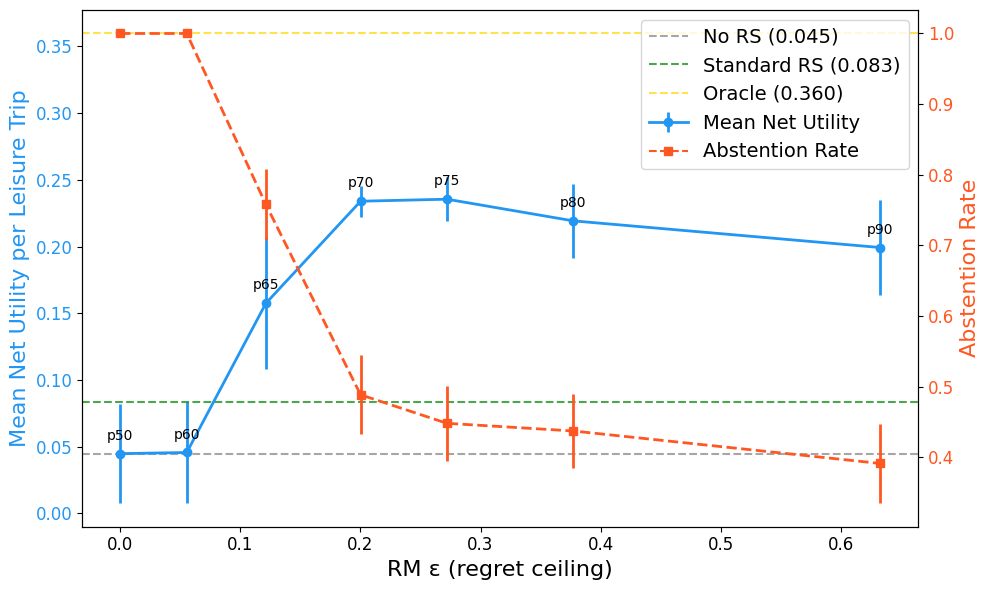

Best RM percentile (max mean U) = p75 (ε = 0.2721) at U = 0.2355


In [12]:
# ── Figure 3: RM threshold frontier ─────────────────────────────────────
fig, ax1 = plt.subplots(figsize=(10, 6))

eps_vals = [rm_results[p]['epsilon'] for p in RM_PERCENTILES]
rm_mu    = [np.mean([r['mean_utility']    for r in rm_results[p]['runs']]) for p in RM_PERCENTILES]
rm_mu_s  = [np.std ([r['mean_utility']    for r in rm_results[p]['runs']]) for p in RM_PERCENTILES]
rm_ab    = [np.mean([r['abstention_rate'] for r in rm_results[p]['runs']]) for p in RM_PERCENTILES]
rm_ab_s  = [np.std ([r['abstention_rate'] for r in rm_results[p]['runs']]) for p in RM_PERCENTILES]

ax1.errorbar(eps_vals, rm_mu, yerr=rm_mu_s, color=color_u, marker='o', linewidth=2, label='Mean Net Utility')
ax1.axhline(no_rs_mu,  color='gray',  linestyle='--', alpha=0.7, label=f'No RS ({no_rs_mu:.3f})')
ax1.axhline(std_mu,    color='green', linestyle='--', alpha=0.7, label=f'Standard RS ({std_mu:.3f})')
ax1.axhline(oracle_mu, color='gold',  linestyle='--', alpha=0.7, label=f'Oracle ({oracle_mu:.3f})')
ax1.set_xlabel('RM ε (regret ceiling)', fontsize=16)
ax1.set_ylabel('Mean Net Utility per Leisure Trip', color=color_u, fontsize=16)
ax1.tick_params(axis='y', labelcolor=color_u, labelsize=12)
ax1.tick_params(axis='x', labelsize=12)

ax2 = ax1.twinx()
ax2.errorbar(eps_vals, rm_ab, yerr=rm_ab_s, color=color_a, marker='s', linewidth=2, linestyle='--')
ax2.set_ylabel('Abstention Rate', color=color_a, fontsize=16)
ax2.tick_params(axis='y', labelcolor=color_a, labelsize=12)

for p, e, mu in zip(RM_PERCENTILES, eps_vals, rm_mu):
    ax1.annotate(f'p{p}', (e, mu), textcoords='offset points', xytext=(0, 10),
                 fontsize=10, ha='center')

lines1, _ = ax1.get_legend_handles_labels()
abst_line = Line2D([0], [0], color=color_a, marker='s', linestyle='--', label='Abstention Rate')
ax1.legend(handles=lines1 + [abst_line], fontsize=14)
plt.tight_layout()
plt.show()

best_p = RM_PERCENTILES[int(np.argmax(rm_mu))]
print(f'Best RM percentile (max mean U) = p{best_p} '
      f'(ε = {rm_epsilons[best_p]:.4f}) at U = {max(rm_mu):.4f}')

In [9]:
# ── Table 1: Aggregate welfare metrics across the six treatments ───────
rows = []
for treatment in TREATMENTS:
    tname = treatment['name']
    runs  = [results[(tname, s)] for s in SEEDS]
    rows.append({
        'Condition':  DISPLAY_NAMES[tname],
        r'$\bar{U}$': np.mean([r['mean_utility']    for r in runs]),
        r'$\sigma_U$': np.std ([r['mean_utility']    for r in runs]),
        'Neg. rate':  np.mean([r['neg_utility_rate'] for r in runs]),
        'Abst.':      np.mean([r['abstention_rate'] for r in runs]),
        'Gini':       np.mean([r['gini']            for r in runs]),
    })
table1 = pd.DataFrame(rows)
print('Table 1: Aggregate welfare metrics by recommendation condition')
print(table1.to_string(index=False, float_format='%.3f'))
table1

Table 1: Aggregate welfare metrics by recommendation condition
             Condition  $\bar{U}$  $\sigma_U$  Neg. rate  Abst.  Gini
                 No RS      0.045       0.037      0.432  1.000 0.187
           Standard RS      0.083       0.029      0.376  0.367 0.155
               PUP-0.3      0.247       0.013      0.231  0.435 0.154
               PUP-0.7      0.247       0.013      0.239  0.545 0.136
RM ($\epsilon$=0.2721)      0.236       0.017      0.230  0.448 0.150
                Oracle      0.360       0.026      0.194  0.400 0.153


,Condition,$\bar{U}$,$\sigma_U$,Neg. rate,Abst.,Gini
0,No RS,0.044762,0.037181,0.431804,1.000000,0.187085
1,Standard RS,0.083150,0.029131,0.375854,0.366568,0.155174
2,PUP-0.3,0.247375,0.012555,0.230905,0.434643,0.154423
3,PUP-0.7,0.246942,0.013129,0.239137,0.544980,0.135704
4,RM ($\epsilon$=0.2721),0.235517,0.016674,0.229562,0.448288,0.150340
5,Oracle,0.359744,0.026072,0.193850,0.399693,0.152647


## 2. Heterogeneity analysis

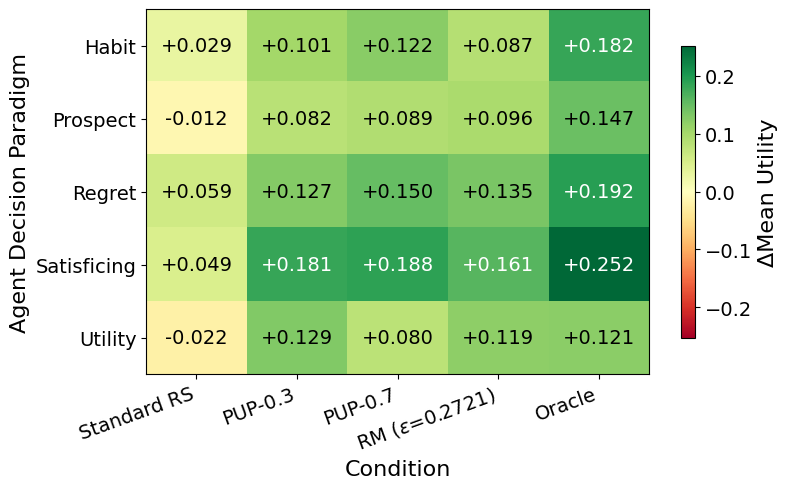

,Standard RS,PUP-0.3,PUP-0.7,RM ($\epsilon$=0.2721),Oracle
Habit,0.028681,0.101013,0.122329,0.086595,0.182285
Prospect,-0.012176,0.081535,0.088756,0.095585,0.147384
Regret,0.059148,0.126870,0.149722,0.134906,0.192009
Satisficing,0.049179,0.181345,0.188220,0.161373,0.252151
Utility,-0.022291,0.128991,0.080243,0.119364,0.120714


In [10]:
# ── Collect per-paradigm per-agent mean utility ─────────────────────────
paradigm_data = defaultdict(lambda: defaultdict(list))
for treatment in TREATMENTS:
    tname = treatment['name']
    for seed in SEEDS:
        for ad in results[(tname, seed)]['agent_data']:
            paradigm_data[tname][ad['paradigm']].append(ad['mean_utility'])

all_paradigms = sorted({p for tn in paradigm_data for p in paradigm_data[tn]})
heatmap_conditions = [t['name'] for t in TREATMENTS if t['name'] != 'no_rs']
heatmap_labels     = [DISPLAY_NAMES[n] for n in heatmap_conditions]

baseline_by_paradigm = {
    p: (np.mean(paradigm_data['no_rs'][p]) if paradigm_data['no_rs'][p] else 0.0)
    for p in all_paradigms
}

matrix = np.zeros((len(all_paradigms), len(heatmap_conditions)))
for j, tname in enumerate(heatmap_conditions):
    for i, p in enumerate(all_paradigms):
        mean_u = np.mean(paradigm_data[tname][p]) if paradigm_data[tname][p] else 0.0
        matrix[i, j] = mean_u - baseline_by_paradigm[p]

LABEL_SIZE, TICK_SIZE, ANNOT_SIZE = 16, 14, 14
fig, ax = plt.subplots(figsize=(8, 5))
vmax = max(abs(matrix.min()), abs(matrix.max()), 1e-6)
im = ax.imshow(matrix, cmap='RdYlGn', aspect='auto', vmin=-vmax, vmax=vmax)

ax.set_xticks(range(len(heatmap_conditions)))
ax.set_xticklabels(heatmap_labels, fontsize=TICK_SIZE, rotation=20, ha='right')
ax.set_yticks(range(len(all_paradigms)))
ax.set_yticklabels([p.capitalize() for p in all_paradigms], fontsize=TICK_SIZE)

for i in range(len(all_paradigms)):
    for j in range(len(heatmap_conditions)):
        val   = matrix[i, j]
        color = 'white' if abs(val) > vmax * 0.6 else 'black'
        ax.text(j, i, f'{val:+.3f}', ha='center', va='center',
                fontsize=ANNOT_SIZE, color=color)

ax.set_xlabel('Condition', fontsize=LABEL_SIZE)
ax.set_ylabel('Agent Decision Paradigm', fontsize=LABEL_SIZE)
cbar = plt.colorbar(im, ax=ax, shrink=0.8)
cbar.set_label(u'\u0394Mean Utility', fontsize=LABEL_SIZE)
cbar.ax.tick_params(labelsize=TICK_SIZE)
plt.tight_layout()
plt.show()

paradigm_table = pd.DataFrame(
    matrix, index=[p.capitalize() for p in all_paradigms], columns=heatmap_labels
)
paradigm_table

## 3. Cost of over-recommendation

In [11]:
# ── Over-recommendation cost (ORC) table ────────────────────────────────
NEUTRAL = 1e-9   # anything strictly above 0 counts as improved, strictly below as harmed

orc_rows = []
for treatment in TREATMENTS:
    tname = treatment['name']
    if tname == 'no_rs':
        continue
    harmed_frac, improved_frac, harmed_orc = [], [], []
    for seed in SEEDS:
        baseline = results[('no_rs', seed)]['agent_utilities']
        treat    = results[(tname,    seed)]['agent_utilities']
        common   = sorted(set(baseline) & set(treat))
        u_b = np.array([baseline[a] for a in common])
        u_t = np.array([treat[a]    for a in common])
        diff = u_t - u_b
        harmed_frac.append(float(np.mean(diff < -NEUTRAL)))
        improved_frac.append(float(np.mean(diff >  NEUTRAL)))
        # Mean loss per harmed agent (not per all agents)
        losses = np.maximum(0.0, u_b - u_t)
        n_harmed = int(np.sum(diff < -NEUTRAL))
        harmed_orc.append(float(np.sum(losses) / n_harmed) if n_harmed else 0.0)
    orc_rows.append({
        'Condition':   DISPLAY_NAMES[tname],
        'Harmed %':    f'{100 * np.mean(harmed_frac):.1f}%',
        'Improved %':  f'{100 * np.mean(improved_frac):.1f}%',
        'Mean ORC':    f'{np.mean(harmed_orc):.3f} ± {np.std(harmed_orc):.3f}',
    })

orc_table = pd.DataFrame(orc_rows)
print('Table 2: Over-recommendation cost (ORC) by condition')
print(orc_table.to_string(index=False))
orc_table

Table 2: Over-recommendation cost (ORC) by condition
             Condition Harmed % Improved %      Mean ORC
           Standard RS    37.7%      44.0% 0.387 ± 0.023
               PUP-0.3    29.2%      54.0% 0.345 ± 0.029
               PUP-0.7    30.8%      53.5% 0.343 ± 0.016
RM ($\epsilon$=0.2721)    29.6%      53.5% 0.359 ± 0.017
                Oracle    26.7%      55.3% 0.369 ± 0.050


,Condition,Harmed %,Improved %,Mean ORC
0,Standard RS,37.7%,44.0%,0.387 ± 0.023
1,PUP-0.3,29.2%,54.0%,0.345 ± 0.029
2,PUP-0.7,30.8%,53.5%,0.343 ± 0.016
3,RM ($\epsilon$=0.2721),29.6%,53.5%,0.359 ± 0.017
4,Oracle,26.7%,55.3%,0.369 ± 0.050
